##Setup

### Import Packages and Set Constants

In [ ]:
%tensorflow_version 2.x
!pip install tensorflow -q

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory
from google.colab import files
from IPython.display import Image, display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
import PIL
import math
import glob
import json
import os
from tqdm import tqdm
import time
!apt-get update && apt-get -qq install xxd

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,960 kB]
Get:9 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,482 kB]
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRele

In [2]:
MODELS_DIR = 'models'
if not os.path.exists(MODELS_DIR):
  os.mkdir(MODELS_DIR)
SAVED_MODEL_FILENAME = os.path.join(MODELS_DIR, "magic_wand.keras")
FLOAT_TFL_MODEL_FILENAME = os.path.join(MODELS_DIR, "magic_wand_float.tfl")
QUANTIZED_TFL_MODEL_FILENAME = os.path.join(MODELS_DIR, "magic_wand.tfl")
TFL_CC_MODEL_FILENAME = os.path.join(MODELS_DIR, "magic_wand.cc")

DATASET_DIR =  'dataset'
if not os.path.exists(DATASET_DIR):
  os.mkdir(DATASET_DIR)
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "validation")
TEST_DIR = os.path.join(DATASET_DIR, "test")
!rm -rf sample_data

CHKPT_DIR =  'checkpoints'
if not os.path.exists(CHKPT_DIR):
  os.mkdir(CHKPT_DIR)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TEST_PERCENTAGE = 10
VALIDATION_PERCENTAGE = 30
TRAIN_PERCENTAGE = 100 - (TEST_PERCENTAGE + VALIDATION_PERCENTAGE)

### Load Your Custom Dataset
Now you'll need to upload all of your custom gesture files that you created using the Magic Wand tool (aka the ```*.json``` files). **Note: you can select multiple files and upload them all at once!**

If you are having trouble uploading files because your internet bandwidth is too slow feel free to uncomment the lines below to instead use Pete's digits dataset.

In [ ]:
# Upload your files
# os.chdir("/content/dataset")
# uploaded = files.upload()
# os.chdir("/content")

In [3]:
!curl -L https://github.com/petewarden/magic_wand_digit_data/archive/8170591863f9addca27b1a963263f7c7bed33f41.zip -o magic_wand_digit_data.zip
!unzip magic_wand_digit_data.zip
!rm -rf magic_wand_digit_data.zip
!mv magic_wand_digit_data-*/* dataset
!rm -rf magic_wand_digit_data-*

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  238k    0  238k    0     0   249k      0 --:--:-- --:--:-- --:--:--  249k
Archive:  magic_wand_digit_data.zip
8170591863f9addca27b1a963263f7c7bed33f41
   creating: magic_wand_digit_data-8170591863f9addca27b1a963263f7c7bed33f41/
  inflating: magic_wand_digit_data-8170591863f9addca27b1a963263f7c7bed33f41/LICENSE  
  inflating: magic_wand_digit_data-8170591863f9addca27b1a963263f7c7bed33f41/petewarden_0.json  
  inflating: magic_wand_digit_data-8170591863f9addca27b1a963263f7c7bed33f41/petewarden_1.json  
  inflating: magic_wand_digit_data-8170591863f9addca27b1a963263f7c7bed33f41/petewarden_2.json  
  inflating: magic_wand_digit_data-8170591863f9addca27b1a963263f7c7bed33f41/petewarden_3.json  
  inflating: magic_wand_digit_data-8170591863f9addca27b1a963

**Update the variable below with the number of labeled gestures in your dataset**
Note: Use the number of unique gestures/labels and *not* the number of samples in your dataset.

In [4]:
NUM_GESTURES = 10 # UPDATE THIS WITH THE NUMBER OF UNIQUE GESTURES IN YOUR DATASET #

Next we'll parse the JSON files into a python object which we can more easily work with.

In [5]:
dataset_jsons = DATASET_DIR + "/*.json"
strokes = []
for filename in sorted(glob.glob(dataset_jsons)): # Added sorted()
  print(filename)
  with open(filename, "r") as file:
    file_contents = file.read()
  file_data = json.loads(file_contents)
  for stroke in file_data["strokes"]:
    stroke["filename"] = filename
    strokes.append(stroke)
print(len(strokes))
print(stroke["filename"])
print(dataset_jsons)

dataset/petewarden_0.json
dataset/petewarden_1.json
dataset/petewarden_2.json
dataset/petewarden_3.json
dataset/petewarden_4.json
dataset/petewarden_5.json
dataset/petewarden_6.json
dataset/petewarden_7.json
dataset/petewarden_8.json
dataset/petewarden_9.json
1000
dataset/petewarden_9.json
dataset/*.json


If you'd like to visualize any of your gestures you can use the helper function below!

In [6]:
def plot_stroke(stroke):
  x_array = []
  y_array = []
  for coords in stroke["strokePoints"]:
    x_array.append(coords["x"])
    y_array.append(coords["y"])

  fig = plt.figure(figsize=(12.8, 4.8))
  fig.suptitle(stroke["label"])

  ax = fig.add_subplot(131)
  ax.set_xlabel('x')
  ax.set_ylabel('y')
  ax.set_xlim(-0.4, 0.4)
  ax.set_ylim(-0.4, 0.4)
  ax.plot(x_array, y_array)

  plt.show()

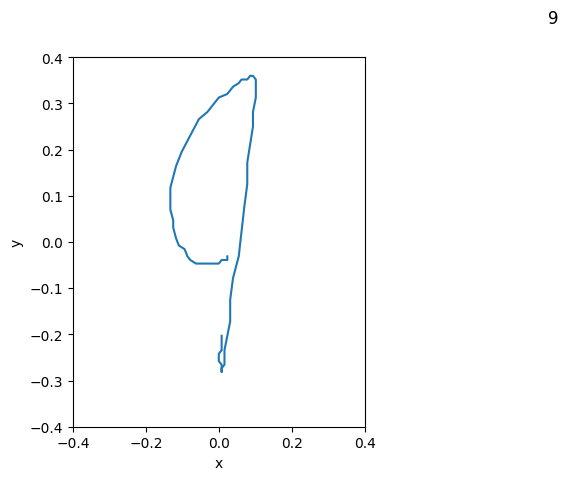

In [7]:
plot_stroke(strokes[980])

### Preprocess your Dataset
Next we'll preprocess the dataset to prepare it for training. By preprocessing the data in bulk before training the whole training process will execute much faster. To do so, we'll convert the strokes into rastered images using the helper functions below. This is the process used in real-time in the Arduino code to convert a gesture into an image that the CNN we are going to train can then process.

Once we have converted the dataset to rasterized images we will generate a ```Keras``` dataset for use in training.

In [8]:
FIXED_POINT = 256

def mul_fp(a, b):
  return (a * b) / FIXED_POINT

def div_fp(a, b):
  if b == 0:
    b = 1
  return (a * FIXED_POINT) / b

def float_to_fp(a):
  return math.floor(a * FIXED_POINT)

def norm_to_coord_fp(a, range_fp, half_size_fp):
  a_fp = float_to_fp(a)
  norm_fp = div_fp(a_fp, range_fp)
  return mul_fp(norm_fp, half_size_fp) + half_size_fp

def round_fp_to_int(a):
  return math.floor((a + (FIXED_POINT / 2)) / FIXED_POINT)

def gate(a, min, max):
  if a < min:
    return min
  elif a > max:
    return max
  else:
    return a

def rasterize_stroke(stroke_points, x_range, y_range, width, height):
  num_channels = 3
  buffer_byte_count = height * width * num_channels
  buffer = bytearray(buffer_byte_count)

  width_fp = width * FIXED_POINT
  height_fp = height * FIXED_POINT
  half_width_fp = width_fp / 2
  half_height_fp = height_fp / 2
  x_range_fp = float_to_fp(x_range)
  y_range_fp = float_to_fp(y_range)

  t_inc_fp = FIXED_POINT / len(stroke_points)

  one_half_fp = (FIXED_POINT / 2)

  for point_index in range(len(stroke_points) - 1):
    start_point = stroke_points[point_index]
    end_point = stroke_points[point_index + 1]
    start_x_fp = norm_to_coord_fp(start_point["x"], x_range_fp, half_width_fp)
    start_y_fp = norm_to_coord_fp(-start_point["y"], y_range_fp, half_height_fp)
    end_x_fp = norm_to_coord_fp(end_point["x"], x_range_fp, half_width_fp)
    end_y_fp = norm_to_coord_fp(-end_point["y"], y_range_fp, half_height_fp)
    delta_x_fp = end_x_fp - start_x_fp
    delta_y_fp = end_y_fp - start_y_fp

    t_fp = point_index * t_inc_fp
    if t_fp < one_half_fp:
      local_t_fp = div_fp(t_fp, one_half_fp)
      one_minus_t_fp = FIXED_POINT - local_t_fp
      red = round_fp_to_int(one_minus_t_fp * 255)
      green = round_fp_to_int(local_t_fp * 255)
      blue = 0
    else:
      local_t_fp = div_fp(t_fp - one_half_fp, one_half_fp)
      one_minus_t_fp = FIXED_POINT - local_t_fp
      red = 0
      green = round_fp_to_int(one_minus_t_fp * 255)
      blue = round_fp_to_int(local_t_fp * 255)
    red = gate(red, 0, 255)
    green = gate(green, 0, 255)
    blue = gate(blue, 0, 255)

    if abs(delta_x_fp) > abs(delta_y_fp):
      line_length = abs(round_fp_to_int(delta_x_fp))
      if delta_x_fp > 0:
        x_inc_fp = 1 * FIXED_POINT
        y_inc_fp = div_fp(delta_y_fp, delta_x_fp)
      else:
        x_inc_fp = -1 * FIXED_POINT
        y_inc_fp = -div_fp(delta_y_fp, delta_x_fp)
    else:
      line_length = abs(round_fp_to_int(delta_y_fp))
      if delta_y_fp > 0:
        y_inc_fp = 1 * FIXED_POINT
        x_inc_fp = div_fp(delta_x_fp, delta_y_fp)
      else:
        y_inc_fp = -1 * FIXED_POINT
        x_inc_fp = -div_fp(delta_x_fp, delta_y_fp)
    for i in range(line_length + 1):
      x_fp = start_x_fp + (i * x_inc_fp)
      y_fp = start_y_fp + (i * y_inc_fp)
      x = round_fp_to_int(x_fp)
      y = round_fp_to_int(y_fp)
      if (x < 0) or (x >= width) or (y < 0) or (y >= height):
        continue
      buffer_index = (y * width * num_channels) + (x * num_channels)
      buffer[buffer_index + 0] = red
      buffer[buffer_index + 1] = green
      buffer[buffer_index + 2] = blue

  np_buffer = np.frombuffer(buffer, dtype=np.uint8).reshape(height, width, num_channels)

  return np_buffer

In [9]:
X_RANGE = 0.6
Y_RANGE = 0.6

def ensure_empty_dir(dirname):
  dirpath = Path(dirname)
  if dirpath.exists() and dirpath.is_dir():
    shutil.rmtree(dirpath)
  dirpath.mkdir()

def augment_points(points, move_range, scale_range, rotate_range):
  move_x = np.random.uniform(low=-move_range, high=move_range)
  move_y = np.random.uniform(low=-move_range, high=move_range)
  scale = np.random.uniform(low=1.0-scale_range, high=1.0+scale_range)
  rotate = np.random.uniform(low=-rotate_range, high=rotate_range)

  x_axis_x = math.cos(rotate) * scale
  x_axis_y = math.sin(rotate) * scale

  y_axis_x = -math.sin(rotate) * scale
  y_axis_y = math.cos(rotate) * scale

  new_points = []
  for point in points:
    old_x = point["x"]
    old_y = point["y"]
    new_x = (x_axis_x * old_x) + (x_axis_y * old_y) + move_x
    new_y = (y_axis_x * old_x) + (y_axis_y * old_y) + move_y
    new_points.append({"x": new_x, "y": new_y})

  return new_points

def save_strokes_as_images(strokes, root_folder, width, height, augment_count):
  ensure_empty_dir(root_folder)
  labels = set()
  for stroke in strokes:
    labels.add(stroke["label"].lower())
  for label in labels:
    label_path = Path(root_folder, label)
    ensure_empty_dir(label_path)

  label_counts = {}
  for stroke in strokes:
    points = stroke["strokePoints"]
    label = stroke["label"].lower()
    if label == "":
      raise Exception("Missing label for %s:%d" % (stroke["filename"], stroke["index"]))
    if label not in label_counts:
      label_counts[label] = 0
    label_count = label_counts[label]
    label_counts[label] += 1
    raster = rasterize_stroke(points, X_RANGE, Y_RANGE, width, height)
    image = PIL.Image.fromarray(raster)
    image.save(Path(root_folder, label, str(label_count) + ".png"))
    for i in range(augment_count):
      augmented_points = augment_points(points, 0.1, 0.1, 0.3)
      raster = rasterize_stroke(augmented_points, X_RANGE, Y_RANGE, width, height)
      image = PIL.Image.fromarray(raster)
      image.save(Path(root_folder, label, str(label_count) + "_a" + str(i) + ".png"))
  return labels

Take the dataset and shuffle it into the Training/Validation/Test splits

In [10]:
IMAGE_WIDTH = 32
IMAGE_HEIGHT = 32


shuffled_strokes = strokes.copy()
np.random.shuffle(shuffled_strokes)

test_count = math.floor((len(shuffled_strokes) * TEST_PERCENTAGE) / 100)
validation_count = math.floor((len(shuffled_strokes) * VALIDATION_PERCENTAGE) / 100)
test_strokes = shuffled_strokes[0:test_count]
validation_strokes = shuffled_strokes[test_count:(test_count + validation_count)]
train_strokes = shuffled_strokes[(test_count + validation_count):]

labels_test  = save_strokes_as_images(test_strokes, TEST_DIR, IMAGE_WIDTH, IMAGE_HEIGHT, NUM_GESTURES)
labels_val   = save_strokes_as_images(validation_strokes, VAL_DIR, IMAGE_WIDTH, IMAGE_HEIGHT, NUM_GESTURES)
labels_train = save_strokes_as_images(train_strokes, TRAIN_DIR, IMAGE_WIDTH, IMAGE_HEIGHT, NUM_GESTURES)

Also get the alphanumeric ordering of the labels as the Nueral Network will output its result in this order for the predicted class. **Make a note of this ordering as you will need to enter the labels in order in the Arduino code!**

In [11]:
labels = sorted(labels_test.union(labels_val).union(labels_train))

labelToInt = {}
currInt = 0
for label in labels:
  labelToInt[label] = currInt
  currInt = currInt + 1
intToLabel = {v: k for k, v in labelToInt.items()}
print(intToLabel)

{0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9'}


If you'd like to visualize the difference between a stroke and its rasterized output image, run the cell below!

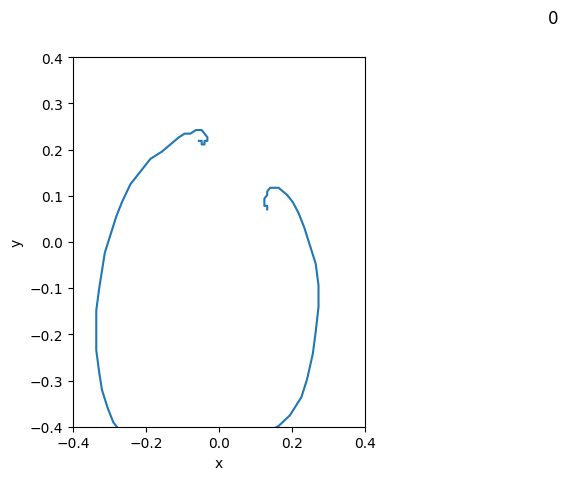

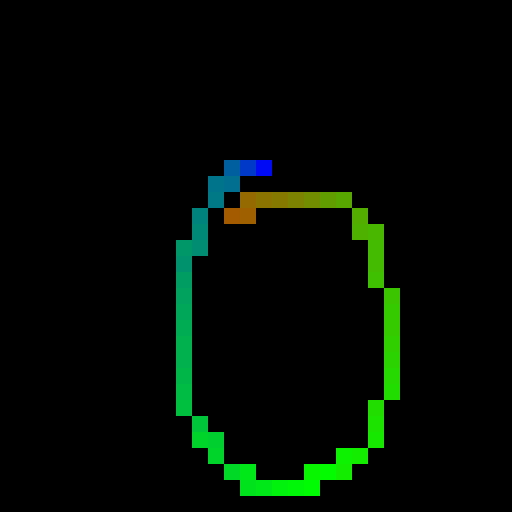

In [12]:
plot_stroke(strokes[4])
raster = rasterize_stroke(strokes[0]["strokePoints"], 0.5, 0.5, 32, 32)
PIL.Image.fromarray(raster).resize((512, 512), PIL.Image.NEAREST)

Finally, we'll generate a dataset in ```Keras```.

In [13]:
validation_ds = image_dataset_from_directory(
    directory=VAL_DIR,
    labels='inferred',
    label_mode='categorical',
    batch_size=32,
    image_size=(IMAGE_WIDTH, IMAGE_HEIGHT)).prefetch(buffer_size=32)

train_ds = image_dataset_from_directory(
    directory=TRAIN_DIR,
    labels='inferred',
    label_mode='categorical',
    batch_size=32,
    image_size=(IMAGE_WIDTH, IMAGE_HEIGHT)).prefetch(buffer_size=32)


test_ds = image_dataset_from_directory(
    directory=TEST_DIR,
    labels='inferred',
    label_mode='categorical',
    batch_size=32,
    image_size=(IMAGE_WIDTH, IMAGE_HEIGHT)).prefetch(buffer_size=32)

Found 3300 files belonging to 10 classes.
Found 6600 files belonging to 10 classes.
Found 1100 files belonging to 10 classes.


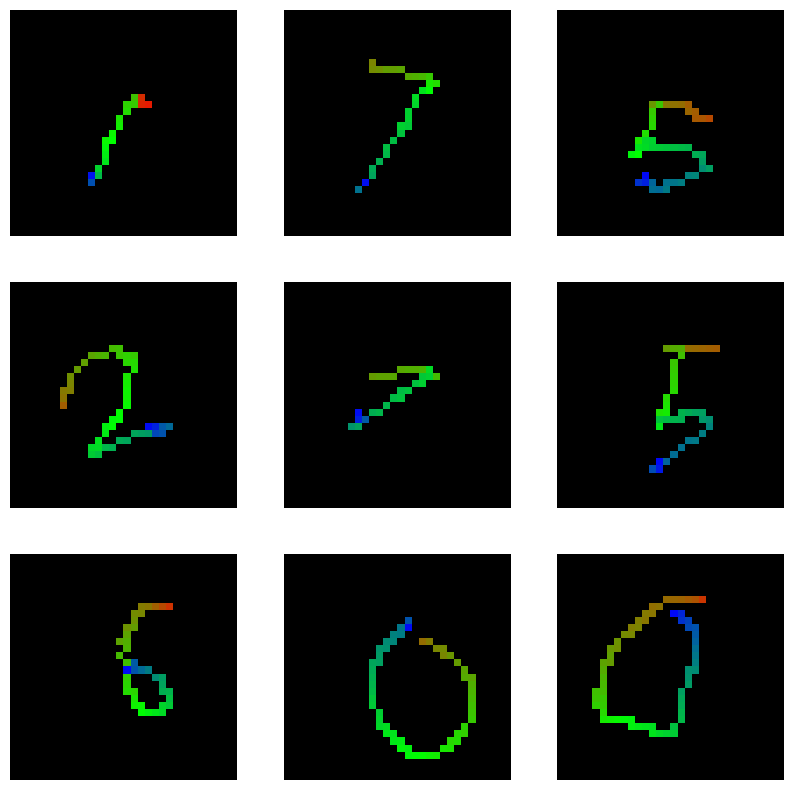

In [14]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.axis("off")

## Define your Model

ResNet

In [15]:
def residual_block(x, filters, stride=1):
    shortcut = x

    x = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, 3, strides=1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)

    return x

def create_resnet(input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 3), num_classes=NUM_GESTURES):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(64, 7, strides=2, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)

    x = residual_block(x, 64)
    x = residual_block(x, 64)
    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs, name='ResNet')

model_resnet = create_resnet()
model_resnet.summary()

Model: "ResNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 16, 16,    │      9,408 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 16, 16,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 8, 8, 64)  │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 8, 8, 64)  │     36,864 │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 8, 8, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 64)  │     36,864 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 8, 8, 64)  │          0 │ batch_normalizat… │
│                     │                   │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 8, 8, 64)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 8, 64)  │     36,864 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 8, 8, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 8, 8, 64)  │     36,864 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 8, 8, 64)  │          0 │ batch_normalizat… │
│                     │                   │            │ activation_2[0][

 Total params: 720,586 (2.75 MB)

 Trainable params: 718,666 (2.74 MB)

 Non-trainable params: 1,920 (7.50 KB)

Yolo

In [16]:
def create_yolo_style(input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 3), num_classes=NUM_GESTURES):
    def conv_block(x, filters, kernel_size=3):
        x = layers.Conv2D(filters, kernel_size, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(alpha=0.1)(x)
        return x

    inputs = layers.Input(shape=input_shape)

    x = conv_block(inputs, 32, 3)
    x = layers.MaxPooling2D(2, 2)(x)

    x = conv_block(x, 64, 3)
    x = layers.MaxPooling2D(2, 2)(x)

    x = conv_block(x, 128, 3)
    x = layers.MaxPooling2D(2, 2)(x)

    x = conv_block(x, 256, 3)
    x = layers.MaxPooling2D(2, 2)(x)

    x = conv_block(x, 512, 3)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(512, activation='leaky_relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs, name='YOLO_Style')

model_yolo = create_yolo_style()
model_yolo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "YOLO_Style"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 4, 4, 256)      │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 2, 2, 512)      │     1,179,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 2, 2, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,65

 Total params: 1,839,338 (7.02 MB)

 Trainable params: 1,837,354 (7.01 MB)

 Non-trainable params: 1,984 (7.75 KB)

MobileViT

In [17]:

def mobile_vit_block(x, expansion=4, transformer_dim=16, num_transformer_blocks=2, num_heads=4):
    shortcut = x
    in_channels = int(x.shape[-1])

    x = layers.Conv2D(expansion * in_channels, 1, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)

    x = layers.DepthwiseConv2D(3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)

    x = layers.Conv2D(transformer_dim, 1, use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    h = int(x.shape[1])
    w = int(x.shape[2])
    c = int(x.shape[3])

    x = layers.Reshape((h * w, c))(x)

    for _ in range(num_transformer_blocks):
        x1 = layers.LayerNormalization(epsilon=1e-6)(x)
        attn = layers.MultiHeadAttention(
            num_heads=min(num_heads, max(1, c // 4)),
            key_dim=max(1, c // max(1, min(num_heads, max(1, c // 4))))
        )(x1, x1)
        x = layers.Add()([x, attn])

        x2 = layers.LayerNormalization(epsilon=1e-6)(x)
        mlp = layers.Dense(c * 2, activation='swish')(x2)
        mlp = layers.Dense(c)(mlp)
        x = layers.Add()([x, mlp])

    x = layers.Reshape((h, w, c))(x)

    x = layers.Conv2D(in_channels, 1, use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([x, shortcut])
    return x

def create_mobilevit(input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 3), num_classes=NUM_GESTURES):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(16, 3, strides=2, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)

    x = mobile_vit_block(x, expansion=2, transformer_dim=16, num_transformer_blocks=1)
    x = layers.MaxPooling2D(2, 2)(x)

    x = mobile_vit_block(x, expansion=4, transformer_dim=24, num_transformer_blocks=2)
    x = layers.MaxPooling2D(2, 2)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='swish')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs, name='MobileViT')

model_mobilevit = create_mobilevit()
model_mobilevit.summary()


Model: "MobileViT"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 16, 16,    │        432 │ input_layer_2[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │         64 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 16, 16,    │        512 │ activation_9[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        128 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 16, 16,    │        288 │ activation_10[0]… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        128 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 16, 16,    │        512 │ activation_11[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │         64 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 256, 16)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 256, 16)   │         32 │ reshape[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 16)   │      1,088 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 256, 16)   │          0 │ reshape[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 16)   │         32 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 25,530 (99.73 KB)

 Trainable params: 24,970 (97.54 KB)

 Non-trainable params: 560 (2.19 KB)

EfficientNetV2

In [18]:
def mbconv_block(x, filters, expansion, stride):
    shortcut = x
    in_channels = x.shape[-1]

    x = layers.Conv2D(expansion * in_channels, 1, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)

    x = layers.DepthwiseConv2D(3, strides=stride, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)

    # SE attention
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Reshape((1, 1, expansion * in_channels))(se)
    se = layers.Conv2D(max(1, expansion * in_channels // 4), 1, activation='swish')(se)
    se = layers.Conv2D(expansion * in_channels, 1, activation='sigmoid')(se)
    x = layers.Multiply()([x, se])

    x = layers.Conv2D(filters, 1, use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    # Residuel
    if stride == 1 and in_channels == filters:
        x = layers.Add()([x, shortcut])

    return x

def create_efficientnetv2(input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 3), num_classes=NUM_GESTURES):
    inputs = layers.Input(shape=input_shape)

    # Stem
    x = layers.Conv2D(32, 3, strides=2, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)

    # MBConv
    x = mbconv_block(x, 16, 1, 1)
    x = mbconv_block(x, 24, 6, 2)
    x = mbconv_block(x, 24, 6, 1)
    x = mbconv_block(x, 48, 6, 2)
    x = mbconv_block(x, 48, 6, 1)
    x = mbconv_block(x, 64, 6, 2)
    x = mbconv_block(x, 64, 6, 1)

    # header
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(320, activation='swish')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs, name='EfficientNetV2')

model_efficientnet = create_efficientnetv2()
model_efficientnet.summary()

Model: "EfficientNetV2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 16, 16,    │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        128 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 16, 16,    │      1,024 │ activation_14[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        128 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_2  │ (None, 16, 16,    │        288 │ activation_15[0]… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        128 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ activation_16[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 1, 1, 32)  │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 1, 1, 8)   │        264 │ reshape_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 1, 1, 32)  │        288 │ conv2d_24[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 16, 16,    │          0 │ activation_16[0]… │
│                     │ 32)               │            │ conv2d_25[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 16, 16,    │        512 │ multiply[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │         64 │ conv2d_26[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 16, 16,    │      1,536 │ batch_normalizat

 Total params: 365,506 (1.39 MB)

 Trainable params: 359,362 (1.37 MB)

 Non-trainable params: 6,144 (24.00 KB)

ConvNeXt

In [19]:

def convnext_block(x, filters):
    shortcut = x
    in_channels = int(x.shape[-1])

    x = layers.DepthwiseConv2D(7, padding='same', use_bias=False)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    x = layers.Conv2D(filters * 4, 1, use_bias=False)(x)
    x = layers.Activation('gelu')(x)

    def grn_fn(t):
        gx = keras.ops.mean(keras.ops.square(t), axis=(1, 2), keepdims=True)
        nx = keras.ops.sqrt(gx + 1e-6)
        return t / nx

    x = layers.Lambda(grn_fn)(x)

    x = layers.Conv2D(filters, 1, use_bias=False)(x)

    if in_channels != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same', use_bias=False)(shortcut)

    x = layers.Add()([x, shortcut])
    return x

def create_convnext(input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 3), num_classes=NUM_GESTURES):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(64, 4, strides=4, padding='same')(inputs)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    for _ in range(3):
        x = convnext_block(x, 64)
    x = layers.MaxPooling2D(2, 2, padding='same')(x)

    x = layers.Conv2D(128, 1, padding='same')(x)
    for _ in range(3):
        x = convnext_block(x, 128)
    x = layers.MaxPooling2D(2, 2, padding='same')(x)

    x = layers.Conv2D(256, 1, padding='same')(x)
    for _ in range(3):
        x = convnext_block(x, 256)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Dense(256, activation='gelu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs, name='ConvNeXt')

model_convnext = create_convnext()
model_convnext.summary()


Model: "ConvNeXt"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_51 (Conv2D)  │ (None, 8, 8, 64)  │      3,136 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 8, 64)  │        128 │ conv2d_51[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_9  │ (None, 8, 8, 64)  │      3,136 │ layer_normalizat… │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 8, 64)  │        128 │ depthwise_conv2d… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_52 (Conv2D)  │ (None, 8, 8, 256) │     16,384 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_29       │ (None, 8, 8, 256) │          0 │ conv2d_52[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 8, 8, 256) │          0 │ activation_29[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_53 (Conv2D)  │ (None, 8, 8, 64)  │     16,384 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_15 (Add)        │ (None, 8, 8, 64)  │          0 │ conv2d_53[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_10 │ (None, 8, 8, 64)  │      3,136 │ add_15[0][0]      │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 8, 64)  │        128 │ depthwise_conv2d… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_54 (Conv2D)  │ (None, 8, 8, 256) │     16,384 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_30       │ (None, 8, 8, 256) │          0 │ conv2d_54[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 8, 8, 256) │          0 │ activation_30[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_55 (Conv2D)  │ (None, 8, 8, 64)  │     16,384 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 8, 8, 64)  │          0 │ conv2d_55[0][0],  │
│                     │                   │            │ add_15[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_11 │ (None, 8, 8, 64)  │      3,136 │ add_16[0][0]      │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 8, 64)  │        128 │ depthwise_conv2d… │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 2,246,410 (8.57 MB)

 Trainable params: 2,246,410 (8.57 MB)

 Non-trainable params: 0 (0.00 B)

## Train your Model

Now that we have a preprocessed dataset and a model its time to train that model with that dataset!

In [20]:
EPOCHS = 25

checkpointFileLoc = CHKPT_DIR + "/save_at_{epoch:02d}.h5"

def train_model(model, model_name, validation_ds, train_ds, epochs=EPOCHS, batch_size=64, lr=0.001):
    print(f'\nTraining model{model_name}')

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy', keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')]
    )

    callbacks = [
        keras.callbacks.ReduceLROnPlateau('val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
        keras.callbacks.EarlyStopping('val_accuracy', patience=5, restore_best_weights=True, verbose=1),
        keras.callbacks.ModelCheckpoint(checkpointFileLoc, 'val_accuracy', save_best_only=True, verbose=0)
    ]

    start_time = time.time()
    history = model.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )
    train_time = time.time() - start_time

    test_results = model.evaluate(validation_ds, verbose=0)
    val_acc = test_results[1]
    num_samples = sum(x.shape[0] for x, _ in train_ds)
    samples_per_sec = num_samples / train_time if train_time > 0 else 0


    print(f'\n{model_name} Done')
    print(f' Training time: {train_time:.2f}s')
    print(f' Val acc: {val_acc*100:.2f}%')
    print(f' Params num: {model.count_params():,}')
    print(f' Throughput: {samples_per_sec:.1f} samples/s')

    return history, val_acc, train_time, samples_per_sec

In [22]:
models_config = [
    (model_resnet, 'ResNet'),
    (model_yolo, 'YOLO_Style'),
    (model_mobilevit, 'MobileViT'),
    (model_efficientnet, 'EfficientNetV2'),
    (model_convnext, 'ConvNeXt')
]

all_results = []
trained_models = {}

for model, name in models_config:
  history, val_acc, train_time, sps = train_model(
      model, name, validation_ds ,train_ds,
      epochs=EPOCHS
  )

all_results.append({
    'name': name,
    'params': model.count_params(),
    'val_acc': val_acc,
    'train_time': train_time,
    'samples_per_sec': sps,
    'history': history
})
trained_models[name] = model



Training modelResNet
Epoch 1/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9939 - loss: 0.0198 - precision: 0.9940 - recall: 0.9935

207/207 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.9941 - loss: 0.0204 - precision: 0.9942 - recall: 0.9936 - val_accuracy: 0.9867 - val_loss: 0.0844 - val_precision: 0.9873 - val_recall: 0.9867 - learning_rate: 0.0010
Epoch 2/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9912 - loss: 0.0306 - precision: 0.9920 - recall: 0.9911 - val_accuracy: 0.9815 - val_loss: 0.1043 - val_precision: 0.9818 - val_recall: 0.9809 - learning_rate: 0.0010
Epoch 3/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9959 - loss: 0.0122 - precision: 0.9962 - recall: 0.9958 - val_accuracy: 0.9694 - val_loss: 0.1457 - val_precision: 0.9702 - val_recall: 0.9673 - learning_rate: 0.0010
Epoch 4/25
206/207 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9989 - loss: 0.0044 - precision: 0.9989 - recall: 0.9989
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9979 - loss: 0.0087 - precision: 0.9979 - recall: 

207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9977 - loss: 0.0092 - precision: 0.9977 - recall: 0.9976 - val_accuracy: 0.9909 - val_loss: 0.0729 - val_precision: 0.9918 - val_recall: 0.9909 - learning_rate: 5.0000e-04
Epoch 7/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9992 - loss: 0.0021 - precision: 0.9994 - recall: 0.9992 - val_accuracy: 0.9870 - val_loss: 0.0787 - val_precision: 0.9876 - val_recall: 0.9870 - learning_rate: 5.0000e-04
Epoch 8/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9998 - loss: 6.3404e-04 - precision: 0.9998 - recall: 0.9998 - val_accuracy: 0.9879 - val_loss: 0.0860 - val_precision: 0.9879 - val_recall: 0.9879 - learning_rate: 5.0000e-04
Epoch 9/25
197/207 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 3.4904e-04 - precision: 1.0000 - recall: 1.0000
Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 1.0000 - loss: 2.8971e-04 - precisi

207/207 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.9479 - loss: 0.1715 - precision: 0.9779 - recall: 0.9238 - val_accuracy: 0.7391 - val_loss: 1.3927 - val_precision: 0.7464 - val_recall: 0.7324 - learning_rate: 0.0010
Epoch 2/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9856 - loss: 0.0431 - precision: 0.9863 - recall: 0.9850 - val_accuracy: 0.7242 - val_loss: 2.3490 - val_precision: 0.7250 - val_recall: 0.7236 - learning_rate: 0.0010
Epoch 3/25
199/207 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9918 - loss: 0.0251 - precision: 0.9923 - recall: 0.9918

207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9950 - loss: 0.0158 - precision: 0.9952 - recall: 0.9948 - val_accuracy: 0.9803 - val_loss: 0.1123 - val_precision: 0.9803 - val_recall: 0.9800 - learning_rate: 0.0010
Epoch 4/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9970 - loss: 0.0127 - precision: 0.9970 - recall: 0.9968 - val_accuracy: 0.9694 - val_loss: 0.1723 - val_precision: 0.9699 - val_recall: 0.9679 - learning_rate: 0.0010
Epoch 5/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9959 - loss: 0.0140 - precision: 0.9959 - recall: 0.9958 - val_accuracy: 0.9758 - val_loss: 0.1100 - val_precision: 0.9760 - val_recall: 0.9755 - learning_rate: 0.0010
Epoch 6/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9994 - loss: 0.0018 - precision: 0.9994 - recall: 0.9994 - val_accuracy: 0.9621 - val_loss: 0.3022 - val_precision: 0.9624 - val_recall: 0.9612 - learning_rate: 0.0010
Epoch 7/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9985 - 

...

207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9573 - loss: 0.1449 - precision: 0.9604 - recall: 0.9548 - val_accuracy: 0.9661 - val_loss: 0.1054 - val_precision: 0.9695 - val_recall: 0.9636 - learning_rate: 0.0010
Epoch 3/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9764 - loss: 0.0772 - precision: 0.9788 - recall: 0.9747

207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9827 - loss: 0.0578 - precision: 0.9843 - recall: 0.9815 - val_accuracy: 0.9721 - val_loss: 0.1136 - val_precision: 0.9736 - val_recall: 0.9718 - learning_rate: 0.0010
Epoch 4/25
203/207 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9819 - loss: 0.0654 - precision: 0.9829 - recall: 0.9798

207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9792 - loss: 0.0731 - precision: 0.9805 - recall: 0.9776 - val_accuracy: 0.9818 - val_loss: 0.0806 - val_precision: 0.9821 - val_recall: 0.9815 - learning_rate: 0.0010
Epoch 5/25
202/207 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9869 - loss: 0.0440 - precision: 0.9893 - recall: 0.9861

207/207 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9918 - loss: 0.0254 - precision: 0.9927 - recall: 0.9914 - val_accuracy: 0.9873 - val_loss: 0.0727 - val_precision: 0.9888 - val_recall: 0.9870 - learning_rate: 0.0010
Epoch 6/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9982 - loss: 0.0084 - precision: 0.9983 - recall: 0.9979 - val_accuracy: 0.9839 - val_loss: 0.0854 - val_precision: 0.9851 - val_recall: 0.9836 - learning_rate: 0.0010
Epoch 7/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9994 - loss: 0.0028 - precision: 0.9995 - recall: 0.9992 - val_accuracy: 0.9864 - val_loss: 0.0778 - val_precision: 0.9870 - val_recall: 0.9864 - learning_rate: 0.0010
Epoch 8/25
202/207 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9903 - loss: 0.0412 - precision: 0.9903 - recall: 0.9895
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9862 - loss: 0.0551 - precision: 0.9863 - recall: 

207/207 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 1.0000 - loss: 7.3703e-04 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9885 - val_loss: 0.0659 - val_precision: 0.9885 - val_recall: 0.9885 - learning_rate: 5.0000e-04
Epoch 11/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 1.0000 - loss: 3.2714e-04 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9876 - val_loss: 0.0769 - val_precision: 0.9876 - val_recall: 0.9873 - learning_rate: 5.0000e-04
Epoch 12/25
204/207 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 2.3705e-04 - precision: 1.0000 - recall: 1.0000
Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 1.0000 - loss: 1.8986e-04 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9879 - val_loss: 0.0777 - val_precision: 0.9879 - val_recall: 0.9876 - learning_rate: 5.0000e-04
Epoch 13/25
207/207 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 1.0000 - loss: 1.626

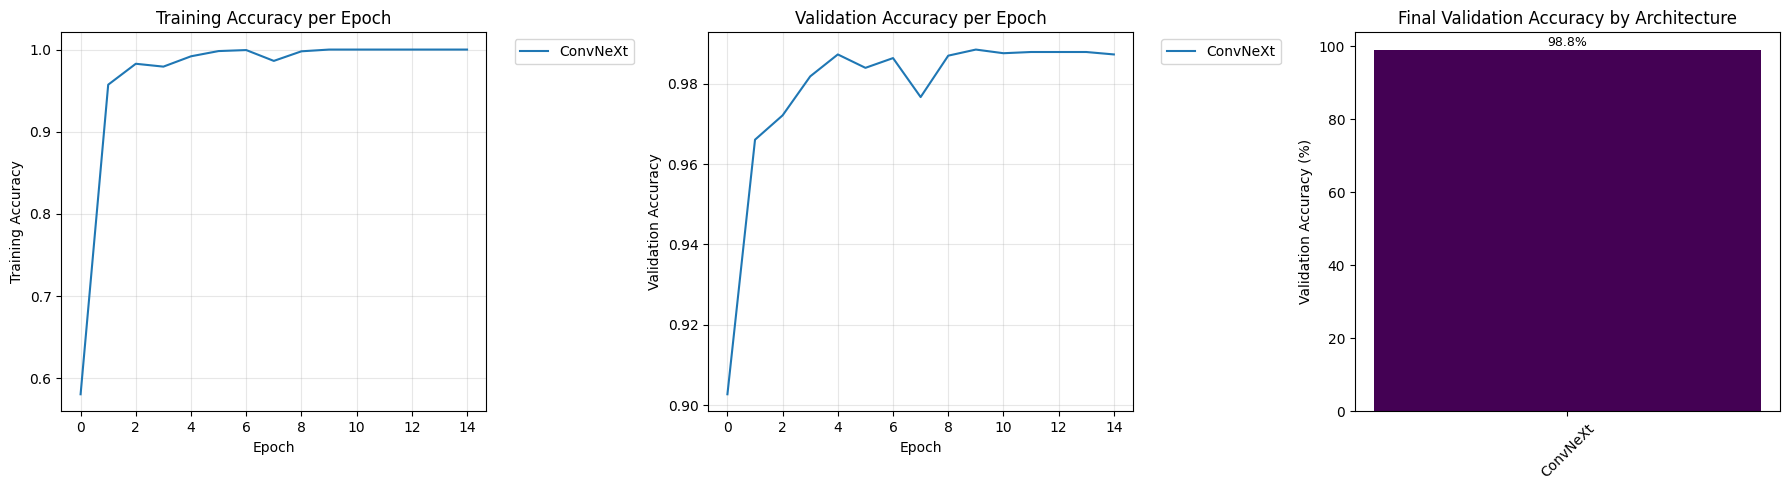

In [23]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
for r in all_results:
    plt.plot(r['history'].history['accuracy'], label=r['name'])
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.title('Training Accuracy per Epoch')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
for r in all_results:
    plt.plot(r['history'].history['val_accuracy'], label=r['name'])
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy per Epoch')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
names = [r['name'] for r in all_results]
accs = [r['val_acc'] * 100 for r in all_results]
colors = plt.cm.viridis(np.linspace(0, 1, len(names)))
bars = plt.bar(names, accs, color=colors)
plt.ylabel('Validation Accuracy (%)')
plt.title('Final Validation Accuracy by Architecture')
plt.xticks(rotation=45)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('architecture_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
header = f'{"Architecture":<16} {"Params":>12} {"Val Acc":>10} {"Train Time":>12} {"Samples/s":>12}'
print('Architecture Comparison Summary')
print('=' * 64)
print(header)
print('-' * 64)

for r in all_results:
  print(f'{r["name"]:<16} {r["params"]:>12,} {r["val_acc"]*100:>9.2f}%'f' {r["train_time"]:>11.2f}s {r["samples_per_sec"]:>12.1f}')

print('='*64)

best_acc = max(all_results, key=lambda x: x['val_acc'])
fastest = min(all_results, key=lambda x: x['train_time'])
smallest = min(all_results, key=lambda x: x['params'])

print(f'\nHighest acc {best_acc["name"]} ({best_acc["val_acc"]*100:.2f}%)')
print(f'Fastest Train：{fastest["name"]} ({fastest["train_time"]:.2f}s)')
print(f'Fewest params：{smallest["name"]} ({smallest["params"]:,} params)')

Architecture Comparison Summary
Architecture           Params    Val Acc   Train Time    Samples/s
----------------------------------------------------------------
ConvNeXt            2,246,410     98.85%       81.82s         80.7

Highest acc ConvNeXt (98.85%)
Fastest Train：ConvNeXt (81.82s)
Fewest params：ConvNeXt (2,246,410 params)


Now, let's evaluate the model on the test dataset.

In [27]:
best_model_name = best_acc['name']
best_model = trained_models[best_model_name]
test_results = best_model.evaluate(test_ds)
test_loss = test_results[0]
test_acc = test_results[1]
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.9909 - loss: 0.0425 - precision: 0.9909 - recall: 0.9900
Test Loss: 0.0425
Test Accuracy: 0.9909


In [29]:
best_model.save(SAVED_MODEL_FILENAME)
print(f'Saved best model ({best_model_name}) to {SAVED_MODEL_FILENAME}')

Saved best model (ConvNeXt) to models/magic_wand.keras


## Test your TensorFlow Model

Lets now test out the TF model on the test dataset. We'll print out any gesture we get wrong as well as the percentage of known gestures correct as well as the number of gestures that were marked as unknown.

Testing Gesture:  6  with datasize:  143
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━

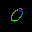

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━

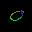

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
0 8 0.9999906
[0] expected, [8] found with score [0.999991]


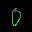

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
0 8 0.995755
[0] expected, [8] found with score [0.995755]


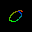

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━

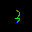

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━

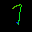

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
7 1 0.98418486
[7] expected, [1] found with score [0.984185]


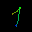

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
7 3 0.81780744
[7] expected, [3] found with score [0.817807]


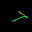

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━

In [30]:
SCORE_THRESHOLD = 0.75

def predict_image(model, filename):
  img = keras.preprocessing.image.load_img(filename, target_size=(IMAGE_WIDTH, IMAGE_HEIGHT))
  img_array = keras.preprocessing.image.img_to_array(img)
  img_array = tf.expand_dims(img_array, 0)
  predictions = model.predict(img_array).flatten()
  predicted_label_index = np.argmax(predictions)
  predicted_score = predictions[predicted_label_index]
  return (predicted_label_index, predicted_score)

correct_count = 0
wrong_count = 0
discarded_count = 0
for label_dir in glob.glob(TEST_DIR + "/*"):
  label = label_dir.replace(TEST_DIR + "/", "")
  print("Testing Gesture: ",label," with datasize: ",len(glob.glob(label_dir + "/*.png")))
  for filename in glob.glob(label_dir + "/*.png"):
    # TODO
    index, score = predict_image(best_model, filename)
    if score < SCORE_THRESHOLD:
      discarded_count += 1
      continue
    if index == labelToInt[label]:
      correct_count += 1
    else:
      wrong_count += 1
      print(label,index,score)
      print("[%s] expected, [%s] found with score [%f]" % (label, intToLabel[index], score))
      display(Image(filename=filename))

if correct_count + wrong_count == 0:
  print("All images marked as unknown!")
else:
  correct_percentage = (correct_count / (correct_count + wrong_count)) * 100
  print("%.1f%% correct (N=%d, %d unknown)" % (correct_percentage, (correct_count + wrong_count), discarded_count))

## Generate a TensorFlow Lite Model

Convert the frozen graph into a TensorFlow Lite model, which is fully quantized for use with embedded devices. The following cell will also print the model size.

In [31]:
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
model_no_quant_tflite = converter.convert()
open(FLOAT_TFL_MODEL_FILENAME, "wb").write(model_no_quant_tflite)


# def representative_dataset():
#   for filename in glob.glob(TEST_DIR + "/*/*.png"):
#     img = keras.preprocessing.image.load_img(filename, target_size=(IMAGE_WIDTH, IMAGE_HEIGHT))
#     img_array = keras.preprocessing.image.img_to_array(img)
#     img_array = tf.expand_dims(img_array, 0)  # Create batch axis for images, labels in train_ds.take(1):
#     yield([img_array])

def representative_dataset():
  for img_batch, _ in train_ds.take(100):
    for i in range(img_batch.shape[0]):
      sample = tf.expand_dims(img_batch[i], 0)
      yield [sample]
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
converter.representative_dataset = representative_dataset
model_tflite = converter.convert()

open(QUANTIZED_TFL_MODEL_FILENAME, "wb").write(model_tflite)

Saved artifact at '/tmp/tmpotnbljmq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor_222')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  134363963692752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134363963693712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134363963695824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134363963694096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134363963694288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134363963695440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134363963696592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134363963695248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134363963694480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134363963695056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13436396369

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


2533024

Compare the sizes of the Tensorflow, TensorFlow Lite and Quantized TensorFlow Lite models.

In [32]:
def get_dir_size(dir):
  size = 0
  for f in os.scandir(dir):
    if f.is_file():
      size += f.stat().st_size
    elif f.is_dir():
      size += get_dir_size(f.path)
  return size

size_tf = os.path.getsize(SAVED_MODEL_FILENAME)
size_no_quant_tflite = os.path.getsize(FLOAT_TFL_MODEL_FILENAME)
size_tflite = os.path.getsize(QUANTIZED_TFL_MODEL_FILENAME)

pd.DataFrame.from_records(
    [["TensorFlow", f"{size_tf} bytes", ""],
     ["TensorFlow Lite", f"{size_no_quant_tflite} bytes ", f"(reduced by {size_tf - size_no_quant_tflite} bytes)"],
     ["TensorFlow Lite Quantized", f"{size_tflite} bytes", f"(reduced by {size_no_quant_tflite - size_tflite} bytes)"]],
     columns = ["Model", "Size", ""], index="Model")

,Size,
Model,,
TensorFlow,27248997 bytes,
TensorFlow Lite,9043092 bytes,(reduced by 18205905 bytes)
TensorFlow Lite Quantized,2533024 bytes,(reduced by 6510068 bytes)


## Test your TensorFlow Lite Models

Lets now test out the TFLite models (quantized and unquantized) on the test dataset. We'll print out any gesture we get wrong as well as the percentage of known gestures correct as well as the number of gestures that were marked as unknown.

In [33]:
def predict_tflite(tflite_model, filename):
  img = keras.preprocessing.image.load_img(filename, target_size=(IMAGE_WIDTH, IMAGE_HEIGHT))
  img_array = keras.preprocessing.image.img_to_array(img)
  img_array = tf.expand_dims(img_array, 0)

  interpreter = tf.lite.Interpreter(model_content=tflite_model)
  interpreter.allocate_tensors()

  input_details = interpreter.get_input_details()[0]
  output_details = interpreter.get_output_details()[0]

  input_scale, input_zero_point = input_details["quantization"]
  if (input_scale, input_zero_point) != (0.0, 0):
    img_array = np.multiply(img_array, 1.0 / input_scale) + input_zero_point
    img_array = img_array.astype(input_details["dtype"])

  interpreter.set_tensor(input_details["index"], img_array)
  interpreter.invoke()
  pred = interpreter.get_tensor(output_details["index"])[0]

  output_scale, output_zero_point = output_details["quantization"]
  if (output_scale, output_zero_point) != (0.0, 0):
    pred = pred.astype(np.float32)
    pred = np.multiply((pred - output_zero_point), output_scale)

  predicted_label_index = np.argmax(pred)
  predicted_score = pred[predicted_label_index]
  return (predicted_label_index, predicted_score)

In [34]:
def run_tflite_test(model_file):
  correct_count = 0
  wrong_count = 0
  discarded_count = 0
  for label_dir in glob.glob(TEST_DIR + "/*"):
    label = label_dir.replace(TEST_DIR + "/", "")
    print("Testing Gesture: ",label," with datasize: ",len(glob.glob(label_dir + "/*.png")))
    for filename in glob.glob(label_dir + "/*.png"):
      index, score = predict_tflite(model_file, filename)
      if score < SCORE_THRESHOLD:
        discarded_count += 1
        continue
      if index == labelToInt[label]:
        correct_count += 1
      else:
        wrong_count += 1
        print("[%s] expected, [%s] found with score [%f]" % (label, intToLabel[index], score))
        display(Image(filename=filename))

  total = correct_count + wrong_count
  if total == 0:
    print('All images discarded as unknown (score < %.2f).' % SCORE_THRESHOLD)
  else:
    print('%.1f%% correct (N=%d, %d unknown/discarded)' %
              (correct_count / total * 100, total, discarded_count))

First test the float model.

Testing Gesture:  6  with datasize:  143


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Testing Gesture:  5  with datasize:  143
Testing Gesture:  4  with datasize:  66
Testing Gesture:  0  with datasize:  143
[0] expected, [8] found with score [0.959250]


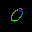

[0] expected, [6] found with score [0.931044]


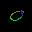

[0] expected, [8] found with score [0.999991]


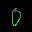

[0] expected, [8] found with score [0.995755]


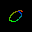

Testing Gesture:  1  with datasize:  66
Testing Gesture:  2  with datasize:  143
Testing Gesture:  8  with datasize:  99
Testing Gesture:  3  with datasize:  110
[3] expected, [1] found with score [0.896659]


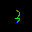

Testing Gesture:  9  with datasize:  99
Testing Gesture:  7  with datasize:  88
[7] expected, [2] found with score [0.897378]


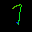

[7] expected, [1] found with score [0.984185]


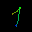

[7] expected, [3] found with score [0.817807]


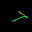

99.3% correct (N=1095, 5 unknown/discarded)


In [35]:
run_tflite_test(model_no_quant_tflite)

Then test the quantized model

Testing Gesture:  3  with datasize:  154
Testing Gesture:  8  with datasize:  99
Testing Gesture:  4  with datasize:  132
Testing Gesture:  7  with datasize:  99
Testing Gesture:  5  with datasize:  110
Testing Gesture:  2  with datasize:  132
Testing Gesture:  6  with datasize:  88
Testing Gesture:  0  with datasize:  77
Testing Gesture:  1  with datasize:  99
Testing Gesture:  9  with datasize:  110
[9] expected, [4] found with score [0.996094]


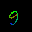

[9] expected, [7] found with score [0.785156]


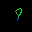

99.8% correct (N=1096, 4 unknown)


In [ ]:
run_tflite_test(model_tflite)

If you'd like to manually evaluate particular images you can uncomment, update, and run the below cell and select an image from the test folder.

In [ ]:
# TEST_IMAGE = # UPDATE ME e.g., "test/0/1.png"
# index, score = predict_tflite(model_no_quant_tflite, TEST_IMAGE)
# print("Float model result:")
# print(index, score) # prints the guessed index and the confidence
# index, score = predict_tflite(model_tflite, TEST_IMAGE)
# print("Quantized model result:")
# print(index, score) # prints the guessed index and the confidence

## Generate a TensorFlow Lite for Microcontrollers Model
To convert the TensorFlow Lite quantized model into a C source file that can be loaded by TensorFlow Lite for Microcontrollers on Arduino we simply need to use the ```xxd``` tool to convert the ```.tflite``` file into a ```.cc``` file.

In [36]:
# # Convert to a C source file, i.e, a TensorFlow Lite for Microcontrollers model
# !xxd -i {QUANTIZED_TFL_MODEL_FILENAME} > {TFL_CC_MODEL_FILENAME}
# # Update variable names
# REPLACE_TEXT = QUANTIZED_TFL_MODEL_FILENAME.replace('/', '_').replace('.', '_')
# !sed -i 's/'{REPLACE_TEXT}'/g_magic_wand_model_data/g' {TFL_CC_MODEL_FILENAME}

import subprocess

replace_text = QUANTIZED_TFL_MODEL_FILENAME.replace('/', '_').replace('.', '_')

result = subprocess.run(
  ['xxd', '-i', QUANTIZED_TFL_MODEL_FILENAME],
  capture_output=True, text=True
)
if result.returncode != 0:
  raise RuntimeError(f'xxd failed: {result.stderr}')

cc_content = result.stdout.replace(replace_text, 'g_magic_wand_model_data')

with open(TFL_CC_MODEL_FILENAME, 'w') as f:
  f.write(cc_content)

print(f'C array written to {TFL_CC_MODEL_FILENAME} ({len(cc_content):,} chars)')


C array written to models/magic_wand.cc (15,620,414 chars)


That's it! You've successfully converted your TensorFlow Lite model into a TensorFlow Lite for Microcontrollers model! Run the cell below to print out its contents which we'll need for our next step, deploying the model using the Arudino IDE!

In [37]:
# # Print the C source file
# !cat {TFL_CC_MODEL_FILENAME}
# # !tail {TFL_CC_MODEL_FILENAME} # run this command to just see the end of the file (aka the size)

with open(TFL_CC_MODEL_FILENAME, 'r') as f:
    cc_text = f.read()

preview_lines = cc_text.splitlines()[:40]
print('\n'.join(preview_lines))
print(f'... ({len(cc_text.splitlines())} lines total)')


unsigned char g_magic_wand_model_data[] = {
  0x1c, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x14, 0x00, 0x20, 0x00,
  0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00, 0x0c, 0x00, 0x00, 0x00,
  0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00,
  0x90, 0x00, 0x00, 0x00, 0x10, 0x01, 0x00, 0x00, 0x50, 0x7d, 0x22, 0x00,
  0x60, 0x7d, 0x22, 0x00, 0x24, 0xa5, 0x26, 0x00, 0x03, 0x00, 0x00, 0x00,
  0x01, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00, 0x4a, 0x50, 0xdd, 0xff,
  0x0c, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00, 0x3c, 0x00, 0x00, 0x00,
  0x0f, 0x00, 0x00, 0x00, 0x73, 0x65, 0x72, 0x76, 0x69, 0x6e, 0x67, 0x5f,
  0x64, 0x65, 0x66, 0x61, 0x75, 0x6c, 0x74, 0x00, 0x01, 0x00, 0x00, 0x00,
  0x04, 0x00, 0x00, 0x00, 0x64, 0xff, 0xff, 0xff, 0x5e, 0x01, 0x00, 0x00,
  0x04, 0x00, 0x00, 0x00, 0x08, 0x00, 0x00, 0x00, 0x6f, 0x75, 0x74, 0x70,
  0x75, 0x74, 0x5f, 0x30, 0x00, 0x00, 0x00, 0x00, 0x01, 0x00, 0x00, 0x00,
  0x04, 0x00, 0x00, 0x00, 0x96, 0x7e, 0xdd, 0xff, 0x04, 0x00, 0x00, 

To download your model for use at a later date:

1. On the left of the UI click on the folder icon
2. Click on the three dots to the right of the ```.cc``` file you just generated and select "download." The file can be found at ```models/{TFL_CC_MODEL_FILENAME}``` which by default is ```models/magic_wand.cc```

Next we'll deploy that model using the Arduino IDE.